# **Mestrado em Ciência de Dados - 2.º Ano**
**Aluno:** Miguel Loureiro | 2220134

**Instituição:** Universidade de Leiria e Oeste  

***Dissertação:*** Data Mining Aplicado à Transformação Digital de uma PME Portuguesa de E-commerce: Um Caso de Estudo Integrado

---

# **Notebook 2. Preparação de Dados**
*O presente notebook contempla a fase de Preparação de Dados inserida na metodologia CRISP-DM, que será aplicada ao caso de estudo da PME do setor pet e agrícola, que atua em contexto de e-commerce.*

---

## **Contextualização do problema em estudo**

### **Domínio de aplicação**

O objeto de estudo assenta numa PME portuguesa do setor pet e agrícola, com forte predominância no segmento de **Aves**. Conforme verificado no notebook anterior, o dataset transacional inclui todas as transações realizadas no período compreendido entre fevereiro de 2016 e março de 2026, abrangendo um horizonte temporal de cerca de 10 anos, com 13.074 clientes únicos registados na base de dados.

### **Objetivo desta fase**

A fase de Preparação de Dados visa transformar os dados explorados na fase anterior num dataset adequado que servirá de base para a fase seguinte de modelação, na qual, numa primeira instância, serão aplicados de algoritmos de classificação supervisionada.

### **Problema de Machine Learning preparado neste notebook**

**Tarefa:** Classificação binária supervisionada, que permite prever se um cliente ativo (com pelo menos 1 compra nos últimos 180 dias) voltará a comprar nos próximos 90 dias.

**Variável alvo:** `Target_Compra` ∈ {0, 1} criada no presente notebook com recurso a uma abordagem de janela temporal.

**Universo:** Clientes com pelo menos 1 transação realizada na janela de features definida (últimos 180 dias antes da janela de target).

**Métrica primária escolhida para a modelação:** Recall, permitindo a minimização de Falsos Negativos.

### **Interpretação da estratégia de janela temporal**

Para evitar o fenómeno de data leakage temporal, é essencial separar o período de extração de features do período de observação do target, de acordo os seguintes critérios:

- **Janela de features (180 dias):** 2025-07-04 → 2025-12-31, correspondendo ao período de onde são extraídas as features comportamentais.
- **Janela de target (90 dias):** 2025-12-31 → 2026-03-31, englobando o período seguinte onde se pretende observar se o cliente voltou a comprar.

### **Estrutura do notebook**

1. Importação de bibliotecas
2. Carregamento e validação de dados
3. Preparação inicial
4. Criação de variáveis RFM (Recency, Frequency, Monetary)
5. Limpeza de dados
6. Feature engineering - Histórico completo
7. Feature engineering - Janela temporal
8. Construção do dataset final e criação da variável alvo `Target_Compra`
9. Análise de correlação
10. Preparação final para modelação
11. Validação do dataset final
12. Exportação do dataset
13. Principais conclusões

### **Outputs deste notebook**
A execução deste notebook resulta na criação do dataset preparado para a fase de modelação:
- **`dataset_modelo_compra.csv`** - dataset de modelação com 12 features + variável alvo `Target_Compra`.

## **1. Importação de bibliotecas**

O primeiro passo consiste na importação das bibliotecas essenciais para manipulação, análise e visualização de dados.

Para tal, são selecionadas as seguintes bibliotecas:
- pandas → estruturação e transformação de dados tabulares
- numpy → operações numéricas
- matplotlib / seaborn → visualização

In [1]:
#Importação das bibliotecas essenciais
import pandas as pd               #manipulação de dataframes
import numpy as np                #operações numéricas
import seaborn as sns             #visualização
import matplotlib.pyplot as plt   #visualização

## **2. Carregamento e validação de dados**

Importadas as bibliotecas essenciais, procede-se à ligação à Google Drive de forma a aceder aos **três dataframes** criados no notebook de compreensão de dados:

- Dataframe Linhas (`df_linhas`) - dataframe ao nível da linha de venda
- Dataframe Vendas (`df_vendas`) - dataframe ao nível da venda
- Dataframe Clientes (`df_clientes`) - dataframe ao nível do cliente

In [2]:
#Montar a Google Drive para acesso aos ficheiros criados no notebook anterior
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Carregar os 3 dataframes exportados pelo NB2 (Compreensão de Dados)
df = pd.read_csv("/content/drive/MyDrive/df_linhas.csv")            #linha de produto
df_vendas = pd.read_csv("/content/drive/MyDrive/df_vendas.csv")     #agregado por venda
df_clientes = pd.read_csv("/content/drive/MyDrive/df_clientes.csv") #agregado por cliente

### **Tipos de dados**

A verificação do tipo de dados incluídos no dataframe de clientes (`df_clientes`) é um passo essencial, pois permite avaliar a adequação dos tipos de dados a cada atributo.

In [4]:
#Inspecionar a estrutura do dataframe de clientes
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13074 entries, 0 to 13073
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ref Cliente      13074 non-null  int64  
 1   Nome do Cliente  13074 non-null  object 
 2   Frequency        13074 non-null  int64  
 3   Monetary         13074 non-null  float64
 4   Ultima_Compra    13074 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 510.8+ KB


A análise da estrutura de dados do `df_clientes` permite constatar que existem **13.074 registos**, sendo interpretados como o número total de clientes registados na base de clientes da empresa durante o período de análise. Adicionalmente, o dataframe em análise é composto por 5 variáveis:

- `Ref Cliente` - identificador do cliente
- `Nome do Cliente` - nome do cliente
- `Frequency` - número total de compras realizadas
- `Monetary` - valor total gasto
- `Ultima_Compra` - data da última compra

No que diz respeito aos tipos de dados identificados, apenas a variável `Ultima_Compra` não tem associado o tipo de dados correto, apresentando atualmente o tipo "object". Desta forma, deve ser convertida para o tipo "datetime", permitindo criar outras variáveis temporais e realizar análises cronológicas.
As restantes variáveis, principalmente as numéricas, encontram-se definidas corretamente, apresentando os tipos "int64" e "float64".

***Primeiras 5 instâncias***

In [5]:
#Visualizar os 5 primeiros clientes
df_display = df_clientes.head().copy()
# Anonimizar colunas identificáveis
for col in ['Nome do Cliente', 'E-Mail', 'Telemóvel']:
    if col in df_display.columns:
        df_display[col] = [f'[Anonimizado_{i:03d}]' for i in range(len(df_display))]
df_display

,Ref Cliente,Nome do Cliente,Frequency,Monetary,Ultima_Compra
0,1,[Anonimizado_000],23,1236.54,2025-01-21
1,2,[Anonimizado_001],11,248.09,2025-05-21
2,4,[Anonimizado_002],86,8177.29,2026-03-31
3,5,[Anonimizado_003],1,39.90,2016-02-13
4,7,[Anonimizado_004],99,3982.89,2026-03-22


A análise dos 5 primeiros registos, ou seja, referente aos 5 primeiros clientes registados, evidencia que 2 deles realizaram compras muito recentemente, mantendo uma relação duradoura com a empresa. Nestes dois casos (`Ref Cliente 4` e `Ref Cliente 7`), a última compra foi realizada nos últimos 10 dias de análise, sendo que o cliente com a referência 4 realizou a sua última compra exatamente no último dia do período em análise.
- Ref Cliente 4: última compra em 2026-03-31
- Ref Cliente 7: última compra em 2026-03-22

Adicionalmente, ambos os clientes indicados apresentam uma frequência de compra relevante acima das 85 compras:
- **Ref Cliente 4**: 86 compras
- **Ref Cliente 7**: 99 compras

Outro aspeto relevante a salientar consiste no total gasto dos 5 primeiros clientes, destacando-se que o cliente com maior despesa (8.177,29€) consiste no cliente 4 com um total de 86 compras.

O cliente 7, apesar de ser o cliente com mais compras realizadas (99), apresenta um total gasto significativamente inferior aos 8.177,29€ gastos pelo cliente 4, contando com uma despesa de 3.982,89€. Conclui-se assim que o cliente 7 realiza compras de menor valor.

O cliente com menor de número de compras e total gasto corresponde ao cliente com a referência 5, tendo apenas realizado 1 compra nos primeiros dias do período de análise (2016-02-13), representada por um valor gasto de 39,90€.

## **3. Preparação inicial**

**Conversão de tipos de dados**

Conforme referido anteriormente, a conversão das variáveis temporais para o formato "datetime" é essencial para o cálculo de métricas, tais como a recência, intervalos entre compras e o tempo de relacionamento com o cliente.

Desta forma, são realizas as transformações referidas na variável `Data` dos dataframes `df` e `df_vendas` e na variável `Ultima_Compra` que consta no dataframe `df_clientes`.

In [6]:
#Converter coluna 'Data' e 'Ultima_Compra' para datetime em todos os dataframes, sendo essencial para cálculos temporais (Recency, etc.)
df['Data'] = pd.to_datetime(df['Data'])
df_vendas['Data'] = pd.to_datetime(df_vendas['Data'])
df_clientes['Ultima_Compra'] = pd.to_datetime(df_clientes['Ultima_Compra'])

**Valores omissos**

De seguida, verifica-se a existência de valores nulos no dataframe `df_clientes`, de forma a poder avaliar a consistência e completude dos dados.

In [7]:
#Verificar valores em falta no dataframe de clientes
df_clientes.isnull().sum()

,0
Ref Cliente,0
Nome do Cliente,0
Frequency,0
Monetary,0
Ultima_Compra,0


De acordo com a análise realizada, constata-se a ausência de valores nulos em todas as variáveis analisadas, evidenciando um elevado nível de completude do dataset.

Este resultado é relevante, na medida em que não só permite garantir a fiabilidade das próximas análises a realizar, como também permite concluir que não são necessárias técnicas adicionais ao nível de imputação de dados.

**Análise descritiva**

A análise de estatísticas descritivas a realizar neste notebook pretende avaliar a distribuição das variáveis que compõem o dataframe `df_clientes`, identificando eventuais padrões relevantes e assimetrias.

In [8]:
#Estatísticas descritivas para compreender a distribuição das variáveis
df_clientes.describe()

,Ref Cliente,Frequency,Monetary,Ultima_Compra
count,13074.000000,13074.000000,13074.000000,13074
mean,8278.529448,4.281092,292.148875,2022-10-21 04:47:48.104635136
min,1.000000,1.000000,2.400000,2016-02-13 00:00:00
25%,4204.250000,1.000000,35.400000,2020-08-06 00:00:00
50%,8214.000000,1.000000,68.700000,2023-03-09 12:00:00
75%,12340.500000,3.000000,192.500000,2025-06-04 00:00:00
max,16720.000000,174.000000,18431.090000,2026-03-31 00:00:00
std,4759.535032,9.564390,849.567305,NaN


A partir da análise realizada, conclui-se, essencialmente, que:

- O número compras (`Frequency`) apresenta mediana igual a 1, significando que 50% dos clientes da empresa realizou apenas uma compra. Desta forma, conclui-se que a maioria dos clientes compra apenas pontualmente, sendo confirmado através do quartil 3, em que 75% dos clientes não ultrapassa as 3 compras.

- O valor máximo de compras realizadas pelos clientes da empresa corresponde a 174 compras, o que traduz um pequeno número de clientes que apresenta uma frequência de compras elevada.

- O valor gasto (`Monetary`) pelos clientes apresenta uma distribuição assimétrica positiva, constatando-se uma mediana de 68,70€, valor significativamente diferente da média (292,15€). A diferença observada pode ser explicada, juntamente com o desvio padrão elevado (849,57€), pela presença de valores extremos e pela alta variabilidade de comportamento do consumo de clientes.

- A variável `Ultima_Compra` apresenta uma distribuição assimétrica caracterizada por uma elevada concentração de clientes cuja última transação ocorreu em períodos relativamente mais recentes, estando a mediana situada em março de 2023 e o terceiro quartil em junho de 2025, significando que 25% da base de clientes realizou a sua última compra nos últimos 9 meses de observação. O mínimo observado (13 de fevereiro de 2016) corresponde ao início da atividade online da empresa e o primeiro quartil (agosto de 2020) indica que cerca de 25% dos clientes não realiza compras há mais de 5 anos.

Em resumo, verifica-se que o dataframe de clientes é composto por clientes com diferentes perfis, variando entre clientes frequentes com elevado valor gasto e clientes pontuais apenas com 1 compra. Desta forma, confirma-se a importância de realizar uma análise de recompra e a necessidade de executar uma segmentação por ciclo de vida, capaz de distinguir, por exemplo, Clientes VIP, Regulares, Ocasionais e Adormecidos.

## **4. Criação de variáveis RFM**

A presente secção visa criar as variáveis necessárias para a posterior análise RFM. As variáveis `Frequency` e `Monetary` foram criadas no notebook anterior, pelo que segue-se a criação da variável `Recency`.
- `Recency` - identifica o número de dias desde a última compra
- `Frequency` - identifica o número de compras realizadas (criada no notebook anterior)
- `Monetary` - identifica o valor gasto no conjunto das compras realizadas (criada no notebook anterior)

***Recency (dias desde última compra)***

In [9]:
#Recency = nº de dias desde a última compra, calculado em relação à data máxima do dataset
data_ref = df_vendas['Data'].max()        #data de referência

#Subtração de datas devolve Timedelta e .dt.days extrai o número de dias
df_clientes['Recency'] = (data_ref - df_clientes['Ultima_Compra']).dt.days

### **Análise descritiva**

Após a criação das 3 variáveis essenciais à análise RFM, procede-se à análise das estatísticas descritivas com o objetivo de identificar padrões relevantes no comportamento de compra dos clientes.

In [10]:
#Estatísticas descritivas das 3 variáveis RFM
df_clientes[['Recency','Frequency','Monetary']].describe()

,Recency,Frequency,Monetary
count,13074.000000,13074.000000,13074.000000
mean,1256.800138,4.281092,292.148875
std,995.593849,9.564390,849.567305
min,0.000000,1.000000,2.400000
25%,300.000000,1.000000,35.400000
50%,1117.500000,1.000000,68.700000
75%,2063.000000,3.000000,192.500000
max,3699.000000,174.000000,18431.090000


A análise das estatísticas descritivas das variáveis RFM permite concluir que:

- A variável `Recency` apresenta uma mediana de 1.117 dias, implicando que uma parte significativa dos clientes já não realiza compras há mais de 3 anos. A média registada de 1.256 dias e o desvio padrão de 955 dias dizem respeito a valores elevados, permitindo concluir que existe uma elevada dispersão temporal, traduzindo-se na coexistência de clientes ativos recentemente com um número elevado de clientes que já não compra há um período significativo de tempo.

- A variável `Frequency` regista uma mediana igual a 1, permitindo inferir que 50% dos clientes realizou apenas 1 compra. Adicionalmente, o valor máximo regista um total de 174 compras, indicando que um grupo restrito de clientes realiza compras com elevada frequência.

- A variável `Monetary` é caracterizada por uma mediana de 68,70€ e uma média significativamente superior (292,15€), prevendo a existência de valores extremos que não serão considerados outliers, mas sim compras com um elevado valor. O desvio padrão registado igualmente elevado de 849,57€ permite confirmar a variabilidade elevada associada ao valor gasto.

Em conclusão, as três variáveis RFM são caracterizadas por **distribuições assimétricas fortes e positivas**, evidenciando um elevado número de clientes que realiza poucas compras, mas ao mesmo tempo um reduzido número de clientes associado a uma frequência elevada de compras. Desta forma, salienta-se a importância de uma segmentação adequada de forma a melhorar a qualidade da análise comportamental.

***Primeiras 5 instâncias - Varíaveis RFM***

A verificação dos 5 primeiros registos associado às variáveis RFM permite validar a correta construção das variáveis e observar a estrutura e conteúdo real destas variáveis.

In [11]:
#Validar as 5 primeiras linhas das variáveis RFM
df_clientes[['Recency','Frequency','Monetary']].head()

,Recency,Frequency,Monetary
0,434,23,1236.54
1,314,11,248.09
2,0,86,8177.29
3,3699,1,39.90
4,9,99,3982.89


A partir da verificação dos 5 primeiros registos, constata-se que a:
- **Recência** varia entre 0 e 3.699 dias, ou seja, nos 5 primeiros clientes registados, 2 deles realizaram compras nos últimos 10 dias do período de análise, tratando-se de clientes ativos recentemente. Por outro lado, o cliente com uma recência igual a 3.699 traduz uma única compra há cerca de 10 anos, isto é, no início da atividade online da PME.
- **Frequência** máxima registada consiste em 99 compras, enquanto a miníma é igual a apenas 1 compra.
- Totalidade do **valor gasto** atinge o valor máximo nos 8.177,29€ e o valor mínimo em apenas 39,90€.

Desta forma, evidencia-se uma elevada heterogeneidade nas 3 variáveis em análise ao observar os 5 primeiros clientes registados na empresa.

## **5. Limpeza de dados**

***Análise de valores inconsistentes***

De forma a analisar possíveis inconsistências nos dados, é realizada uma análise de situações em que o valor gasto e a frequência de compras é inferior a 0, tratando-se de casos que não são realistas.

In [12]:
#Verificação de valores inválidos, onde Monetary e Frequency não devem ser <= 0
df_clientes.describe()

#Filtros para identificar inconsistências
df_clientes[df_clientes['Monetary'] <= 0]
df_clientes[df_clientes['Frequency'] <= 0]

,Ref Cliente,Nome do Cliente,Frequency,Monetary,Ultima_Compra,Recency


A observação dos resultados confirma que não existem quaisquer situações associadas a valores gastos inferior a 0, assim como de frequência de compras negativa.

## **6. Feature Engineering - Histórico completo**

Com o objetivo de complementar o conhecimento sobre o comportamento dos clientes da empresa e de enriquecer o dataset a ser utilizado em etapas subsequentes, são criadas as seguintes variáveis, tendo em conta todo o histórico de transações.

- `Ticket_Medio` - valor médio gasto por nº de encomendas
- `Produtos_Medios` - número médio de produtos por compra
- `Num_Produtos_Distintos` - quantidade de produtos distintos comprados por transação
- `Num_Tipos` - número de tipos de produtos diferentes comprados
- `Num_Categorias` - número de categorias de produtos diferentes compradas
- `Num_Marcas` - número de marcas de produtos diferentes comprados
- `Tempo_Cliente` - duração da relação do cliente com a empresa em dias
- `Freq_Mensal` - frequência de compras mensais realizadas
- `Perc_Desconto` - percentagem de desconto obtido nas transações realizadas
- `Dias_Entre_Compras` - número médio de dias realizados entre compras

Importa salientar que na secção seguinte serão criadas as mesmas variáveis, mas restringidas à abordagem de janela temporal:

***Ticket Médio***

In [13]:
#Ticket Médio = valor total gasto / nº de compras = valor médio por transação
df_clientes['Ticket_Medio'] = df_clientes['Monetary'] / df_clientes['Frequency']

In [14]:
#Estatísticas descritivas do Ticket Médio
df_clientes['Ticket_Medio'].describe()

,Ticket_Medio
count,13074.000000
mean,59.004960
std,56.642226
min,2.400000
25%,28.137500
50%,47.336667
75%,69.986875
max,1577.000000


***Número médio de produtos por compra***

In [15]:
#Número médio de produtos comprados por venda para cada cliente
#1º Passo: somar quantidades de produto por (Cliente, Venda)
qt_por_venda = df.groupby(['Ref Cliente', 'Ref Venda'])['Qt'].sum().reset_index()

#2º Passo: calcular a média do nº de produtos por venda, por cliente
produtos_cliente = qt_por_venda.groupby('Ref Cliente')['Qt'].mean()

#Mapear ao dataframe de clientes
df_clientes['Produtos_Medios'] = df_clientes['Ref Cliente'].map(produtos_cliente)

***Diversidade de produtos (quantos produtos diferentes compra)***

In [16]:
#Diversidade de produtos = nº de produtos distintos comprados pelo cliente
#.nunique() conta valores únicos
diversidade = df.groupby('Ref Cliente')['Ref Produto'].nunique()
df_clientes['Num_Produtos_Distintos'] = df_clientes['Ref Cliente'].map(diversidade)

***Diversidade de tipos***

In [17]:
#Diversidade de Tipos = nº de tipos diferentes (Aves, Cães, Gatos, etc.)
tipos = df.groupby('Ref Cliente')['Tipo'].nunique()
df_clientes['Num_Tipos'] = df_clientes['Ref Cliente'].map(tipos)

***Diversidade de categorias***

In [18]:
#Diversidade de Categorias
categorias = df.groupby('Ref Cliente')['Categoria'].nunique()
df_clientes['Num_Categorias'] = df_clientes['Ref Cliente'].map(categorias)

***Diversidade de marcas***

In [19]:
#Diversidade de Marcas
marcas = df.groupby('Ref Cliente')['Marca'].nunique()
df_clientes['Num_Marcas'] = df_clientes['Ref Cliente'].map(marcas)

***Tempo como cliente***

In [20]:
#Tempo como cliente = nº de dias desde a primeira compra até à data de referência
primeira_compra = df.groupby('Ref Cliente')['Data'].min()

df_clientes['Primeira_Compra'] = df_clientes['Ref Cliente'].map(primeira_compra)
df_clientes['Tempo_Cliente'] = (data_ref - df_clientes['Primeira_Compra']).dt.days

***Frequência média de compras por mês***

In [21]:
#Frequência mensal = Frequency / (tempo como cliente em meses)
#Tempo_Cliente está em dias → dividir por 30 para obter meses
df_clientes['Freq_Mensal'] = df_clientes['Frequency'] / (df_clientes['Tempo_Cliente'] / 30)

***Percentagem desconto usufruído***

In [22]:
#Percentagem de desconto = soma dos descontos / total gasto
desconto = df.groupby('Ref Cliente')['Desconto'].sum()
gasto = df.groupby('Ref Cliente')['Total Compra c/IVA'].sum()

df_clientes['Perc_Desconto'] = desconto / gasto

***Número médio de dias entre compras***

In [23]:
#Dias médios entre compras = média dos intervalos entre transações consecutivas
#1º Passo: ordenar por cliente e data
df_vendas = df_vendas.sort_values(['Ref Cliente', 'Data'])

#2º Passo: calcular a diferença em dias entre compras consecutivas do mesmo cliente
df_vendas['Diff_Dias'] = df_vendas.groupby('Ref Cliente')['Data'].diff().dt.days

#3º Passo: média dos intervalos por cliente
dias_medios = df_vendas.groupby('Ref Cliente')['Diff_Dias'].mean()
df_clientes['Dias_Entre_Compras'] = df_clientes['Ref Cliente'].map(dias_medios)

**Validação final**

Finda a criação das variáveis identificadas, procede-se à validação dos 5 primeiros registos com o objetivo de validar a correta criação das variáveis e de observar a estrutura do dataset.

In [24]:
#Visualizar primeiras linhas com todas as variáveis criadas
df_display = df_clientes.head().copy()
# Anonimizar colunas identificáveis
for col in ['Nome do Cliente', 'E-Mail', 'Telemóvel']:
    if col in df_display.columns:
        df_display[col] = [f'[Anonimizado_{i:03d}]' for i in range(len(df_display))]
df_display

,Ref Cliente,Nome do Cliente,Frequency,Monetary,Ultima_Compra,Recency,Ticket_Medio,Produtos_Medios,Num_Produtos_Distintos,Num_Tipos,Num_Categorias,Num_Marcas,Primeira_Compra,Tempo_Cliente,Freq_Mensal,Perc_Desconto,Dias_Entre_Compras
0,1,[Anonimizado_000],23,1236.54,2025-01-21,434,53.762609,1.434783,22,4,11,15,2016-04-13,3639,0.189613,NaN,145.681818
1,2,[Anonimizado_001],11,248.09,2025-05-21,314,22.553636,1.000000,7,5,7,7,2016-09-12,3487,0.094637,0.000000,317.300000
2,4,[Anonimizado_002],86,8177.29,2026-03-31,0,95.084767,5.732558,105,6,12,21,2016-04-10,3642,0.708402,0.006288,42.847059
3,5,[Anonimizado_003],1,39.90,2016-02-13,3699,39.900000,1.000000,1,1,1,1,2016-02-13,3699,0.008110,NaN,NaN
4,7,[Anonimizado_004],99,3982.89,2026-03-22,9,40.231212,9.606061,248,6,22,43,2016-02-15,3697,0.803354,0.001480,37.632653


In [25]:
#Estatísticas descritivas após feature engineering
#Observação: Freq_Mensal é indefinida (inf) para clientes com Tempo_Cliente = 0
#(clientes que se registaram e compraram no último dia do período de análise).
#Substituem-se os inf por NaN para que describe() apresente estatísticas
df_clientes.replace([np.inf, -np.inf], np.nan).describe()

,Ref Cliente,Frequency,Monetary,Ultima_Compra,Recency,Ticket_Medio,Produtos_Medios,Num_Produtos_Distintos,Num_Tipos,Num_Categorias,Num_Marcas,Primeira_Compra,Tempo_Cliente,Freq_Mensal,Perc_Desconto,Dias_Entre_Compras
count,13074.000000,13074.000000,13074.000000,13074,13074.000000,13074.000000,13074.000000,13074.000000,13074.000000,13074.000000,13074.000000,13074,13074.000000,13060.000000,10386.000000,5521.000000
mean,8278.529448,4.281092,292.148875,2022-10-21 04:47:48.104635136,1256.800138,59.004960,4.878501,6.704528,1.284381,2.581918,2.934756,2021-12-14 05:17:39.017898240,1567.779410,0.210147,0.000339,177.067382
min,1.000000,1.000000,2.400000,2016-02-13 00:00:00,0.000000,2.400000,1.000000,1.000000,0.000000,0.000000,0.000000,2016-02-13 00:00:00,0.000000,0.008110,0.000000,0.000000
25%,4204.250000,1.000000,35.400000,2020-08-06 00:00:00,300.000000,28.137500,1.000000,1.000000,1.000000,1.000000,1.000000,2019-11-20 06:00:00,761.000000,0.018301,0.000000,42.000000
50%,8214.000000,1.000000,68.700000,2023-03-09 12:00:00,1117.500000,47.336667,2.000000,2.000000,1.000000,1.000000,1.000000,2022-01-10 00:00:00,1541.000000,0.041580,0.000000,94.500000
75%,12340.500000,3.000000,192.500000,2025-06-04 00:00:00,2063.000000,69.986875,5.000000,5.000000,1.000000,3.000000,3.000000,2024-02-29 00:00:00,2322.750000,0.136767,0.000000,205.500000
max,16720.000000,174.000000,18431.090000,2026-03-31 00:00:00,3699.000000,1577.000000,551.000000,362.000000,11.000000,35.000000,58.000000,2026-03-31 00:00:00,3699.000000,30.000000,0.111111,3351.000000
std,4759.535032,9.564390,849.567305,NaN,995.593849,56.642226,10.374498,15.579712,0.811862,3.143363,4.511299,NaN,978.409138,1.165439,0.003178,255.432134


A partir dos resultados das estatísticas descritivas após feature engineering, destaca-se que a variável:
- `Ticket_Medio` apresenta um valor médio de 59€ e um máximo de 1.577€, demonstrando que a base de clientes da empresa é composta por clientes com compras de valor avultado em simultâneo com compras de valor mais residual, dado o valor mínimo registado de 2,40€.
- `Tempo_Cliente` permite inferir que a duração das relações registadas varia entre um mínimo de 0 dias (clientes que se registaram e compraram no último dia do período em análise) e 3.699 dias (clientes que se registaram e compraram no primeiro dia do período de análise). Adicionalmente, verifica-se um valor médio de 1.567 dias, que se reflete pelo espaço temporal do período em análise e a existência em simultâneo de clientes recentes e clientes com uma relação com a empresa mais duradoura.
- `Freq_Mensal` revela um valor médio de 0,21 compras por mês, traduzindo a reduzida compra mensal por grande parte dos clientes.
- `Dias_Entre_Compras` apresenta uma mediana de cerca de 95 dias, significando que 50% dos clientes que realizaram mais do que uma compra, tende a voltar a comprar num prazo igual ou inferior a 95 dias. Desta forma, conclui-se que metade dos clientes com histórico de recompra apresentam um intervalo entre transações que não ultrapassa os 3 meses, sendo um indicador extremamente relevante para a criação da variável alvo com o objetivo de prever a recompra.

**Importante:**

*   As variáveis criadas nas secções 4 e 6 permitem caracterizar o cliente em todo o seu histórico de compra com a PME e, por isso, serão utilizadas na aplicação de clustering para fins de segmentação por ciclo de vida e por portfólio.
*   As variáveis que serão criadas na secção 8 (com sufixo _FW) são especificamente destinadas à janela temporal de features para que seja possível concretizar a modelação supervisionada de classificação, evitando data leakage temporal.

**Exportação do dataset de clientes enriquecido (para NB5, NB6 e NB7)**

De seguida, exporta-se o dataframe de clientes enriquecido que integra todas as variáveis comportamentais calculadas, tendo em conta o histórico completo de transações. Este dataset é essencial para a etapa de clustering, pois permite evitar a duplicação de cálculos.

In [26]:
df_clientes.to_csv("/content/drive/MyDrive/df_clientes_enriquecido.csv", index=False)

## **7. Feature Engineering - janela temporal**

Na fase de modelação serão aplicados algoritmos de classificação com o intuito de prever se um cliente ativo voltará a comprar num horizonte temporal futuro de 90 dias. O problema pretende responder à seguinte questão: *"Tendo em conta o historial de compras de um cliente que comprou pelo menos uma vez nos últimos 180 dias, qual a probabilidade de ele voltar a comprar nos próximos 90 dias?"*

Para evitar data leakage, isto é, a utilização de informação futura que não estaria disponível no momento da previsão, é definida uma abordagem de janela temporal), que divide temporalmente a construção das variáveis explicativas e da variável alvo. Desta forma, o período de análise é separado em duas janelas distintas:

- **Janela de features** (180 dias): período de onde são extraídas as características comportamentais dos clientes, correspondente a `2025-07-04 → 2025-12-31`. O universo de clientes do modelo é restrito a clientes com pelo menos uma compra nesta janela.
- **Janela de target** (90 dias): período subsequente utilizado para observar se o cliente voltou a comprar, correspondente a `2025-12-31 → 2026-03-31`.

A definição das janelas temporais criadas (`JANELA_TARGET` e `JANELA_FEATURES`) teve em consideração a distribuição da variável `Dias_Entre_Compras` calculada.

Desta forma, constata-se que a **janela de target (90 dias)** vai ao encontro da mediana observada (95 dias), possibilitando capturar o padrão de comportamento de recompra do cliente típico, assim como adotar uma abordagem trimestral que é essencial na definição da estratégia de marketing.

Por outro lado, a **janela de features (180 dias)** é muito próxima da média observada (177 dias), garantindo a cobertura, em média, de um ciclo inteiro de recompra e, no caso do cliente associado à mediana, aproximadamente dois ciclos. Como tal, esta escolha oferece uma abordagem semestral, sendo relevante nas estratégias de marketing, assim como possibilita obter densidade suficiente para a construção robusta das features RFM e de intervalo médio entre compras.

In [27]:
#janela temporal / janela temporal - definição das datas
#Para evitar data leakage, separa-se o período de extração de features do período de observação do target
data_max          = df_vendas['Data'].max()           #2026-03-31 - última data registada no dataset
JANELA_TARGET     = 90                                #90 dias para observação da recompra (justificado pelo carácter trimestral de análise e pela mediana de Dias_Entre_Compras = 95 dias)
JANELA_FEATURES   = 180                               #180 dias para construção de features (justificado pelo carácter semestral de análise e pela calibração à média de Dias_Entre_Compras = 177 dias, capturando aproximadamente 1 ciclo completo de recompra)

#Calcular os limites das janelas (recuando a partir da data máxima)
data_fim_features    = data_max - pd.Timedelta(days=JANELA_TARGET)   #2025-12-31
data_inicio_features = data_fim_features - pd.Timedelta(days=JANELA_FEATURES)  #2025-07-04

print(f"Janela de features:  {data_inicio_features.date()} → {data_fim_features.date()}")
print(f"Janela de target:    {data_fim_features.date()} → {data_max.date()}")

Janela de features:  2025-07-04 → 2025-12-31
Janela de target:    2025-12-31 → 2026-03-31


In [28]:
#Filtrar transações da JANELA DE FEATURES, sendo apenas estes dados que podem ser usados para criar features
df_fw = df[
    (df['Data'] >= data_inicio_features) &
    (df['Data'] < data_fim_features)
].copy()

#Filtrar vendas da mesma janela (versão agregada das vendas)
df_vendas_fw = df_vendas[
    (df_vendas['Data'] >= data_inicio_features) &
    (df_vendas['Data'] < data_fim_features)
].copy()

print(f"Transações na janela de features: {len(df_fw)}")
print(f"Clientes únicos na janela: {df_fw['Ref Cliente'].nunique()}")

Transações na janela de features: 11880
Clientes únicos na janela: 2257


Após aplicação do filtro temporal, verifica-se um total de 11.880 transações na janela de features (2025-07-04 → 2025-12-31) correspondentes a 2.257 clientes únicos.

De seguida, são criadas todas as features tendo em consideração este período temporal, apresentando o sufixo "FW".

***Recency - Janela de Features***

In [29]:
#Recency_FW - dias desde a última compra DENTRO da janela de features
#Importante: usa data_fim_features (não data_max) como referência → sem data leakage
ultima_compra_fw = df_fw.groupby('Ref Cliente')['Data'].max()

#Aplicar a operação cliente a cliente - número de dias até ao fim da janela
recency_fw = ultima_compra_fw.apply(
    lambda data: (data_fim_features - data).days
).astype(int)

print(recency_fw.describe().round(2))

count    2257.00
mean       68.06
std        51.41
min         1.00
25%        24.00
50%        57.00
75%       106.00
max       180.00
Name: Data, dtype: float64


***Frequency - Janela de Features***

In [30]:
#Frequency_FW - número de compras únicas dentro da janela de features
frequency_fw = df_fw.groupby('Ref Cliente')['Ref Venda'].nunique()
print(frequency_fw.describe().round(2))

count    2257.00
mean        2.01
std         1.83
min         1.00
25%         1.00
50%         1.00
75%         2.00
max        15.00
Name: Ref Venda, dtype: float64


***Monetary - Janela de Features***

In [31]:
#Monetary_FW - soma do gasto dentro da janela de features
monetary_fw = df_fw.groupby('Ref Cliente')['Total Compra c/IVA'].sum()
print(monetary_fw.describe().round(2))

count     2257.00
mean       485.99
std       1234.34
min          4.90
25%         52.64
50%        132.00
75%        427.75
max      25137.67
Name: Total Compra c/IVA, dtype: float64


***Ticket Médio - Janela de Features***

In [32]:
#Ticket Médio na janela = Monetary_FW / Frequency_FW
ticket_medio_fw = monetary_fw / frequency_fw
print(ticket_medio_fw.describe().round(2))

count    2257.00
mean      186.80
std       294.21
min         4.90
25%        45.80
50%        91.70
75%       216.14
max      4550.67
dtype: float64


***Nº médio de produtos por venda - Janela de Features***

In [33]:
#Média de Produtos por venda na janela - média do nº de produtos comprados por venda
qt_por_venda_fw = df_fw.groupby(
    ['Ref Cliente', 'Ref Venda'])['Qt'].sum().reset_index()
produtos_medios_fw = qt_por_venda_fw.groupby('Ref Cliente')['Qt'].mean()
print(produtos_medios_fw.describe().round(2))

count    2257.00
mean        5.94
std        11.26
min         1.00
25%         1.00
50%         2.67
75%         5.50
max       154.00
Name: Qt, dtype: float64


***Diversidade de produtos (Nº de produtos, Tipo, Categoria, Marca distintos) - Janela de Features***

In [34]:
#Diversidade na janela - contagens de produtos, categorias, marcas e tipos distintos
num_produtos_fw   = df_fw.groupby('Ref Cliente')['Ref Produto'].nunique()
num_categorias_fw = df_fw.groupby('Ref Cliente')['Categoria'].nunique()
num_marcas_fw     = df_fw.groupby('Ref Cliente')['Marca'].nunique()
num_tipos_fw      = df_fw.groupby('Ref Cliente')['Tipo'].nunique()

print("Num_Produtos_FW:", num_produtos_fw.describe().round(2))
print("\nNum_Categorias_FW:", num_categorias_fw.describe().round(2))
print("\nNum_Marcas_FW:", num_marcas_fw.describe().round(2))
print("\nNum_Tipos_FW:", num_tipos_fw.describe().round(2))

Num_Produtos_FW: count    2257.00
mean        4.04
std         5.22
min         1.00
25%         1.00
50%         2.00
75%         5.00
max        57.00
Name: Ref Produto, dtype: float64

Num_Categorias_FW: count    2257.00
mean        2.28
std         2.02
min         0.00
25%         1.00
50%         1.00
75%         3.00
max        13.00
Name: Categoria, dtype: float64

Num_Marcas_FW: count    2257.00
mean        2.38
std         2.48
min         0.00
25%         1.00
50%         1.00
75%         3.00
max        20.00
Name: Marca, dtype: float64

Num_Tipos_FW: count    2257.00
mean        1.20
std         0.54
min         0.00
25%         1.00
50%         1.00
75%         1.00
max         7.00
Name: Tipo, dtype: float64


***Frequência mensal - Janela de Features***

In [35]:
#Frequência mensal na janela - denominador fixo de 6 meses (180 dias / 30 dias)
#Denominador fixo (em vez de Tempo_Cliente) garante comparabilidade entre clientes
freq_mensal_fw = frequency_fw / (JANELA_FEATURES / 30)
print(freq_mensal_fw.describe().round(4))

count    2257.0000
mean        0.3342
std         0.3055
min         0.1667
25%         0.1667
50%         0.1667
75%         0.3333
max         2.5000
Name: Ref Venda, dtype: float64


***Dias entre compras - Janela de Features***

In [36]:
#Dias entre compras na janela - intervalo médio entre transações consecutivas
df_vendas_fw_sorted = df_vendas_fw.sort_values(['Ref Cliente', 'Data'])
df_vendas_fw_sorted['Diff_Dias'] = df_vendas_fw_sorted.groupby(
    'Ref Cliente')['Data'].diff().dt.days
dias_entre_fw = df_vendas_fw_sorted.groupby('Ref Cliente')['Diff_Dias'].mean()
print(dias_entre_fw.describe().round(2))

count    864.00
mean      47.39
std       33.91
min        0.00
25%       23.84
50%       39.33
75%       64.00
max      177.00
Name: Diff_Dias, dtype: float64


***Percentagem de desconto - Janela de Features***

In [37]:
#Percentagem de desconto na janela
desconto_fw = df_fw.groupby('Ref Cliente')['Desconto'].sum()
gasto_fw = df_fw.groupby('Ref Cliente')['Total Compra c/IVA'].sum()

#fillna(0) - clientes sem desconto registado têm perc=0 (em vez de NaN)
perc_desconto_fw = (desconto_fw / gasto_fw).fillna(0)
print(perc_desconto_fw.describe().round(4))

count    2257.0000
mean        0.0103
std         0.0938
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
max         4.3444
dtype: float64


***Tempo como cliente - Janela de Features***

In [38]:
#Tempo como cliente até ao fim da janela de features
#Usa-se a primeira compra histórica (mesmo antes da janela) - informação que já existia em data_fim_features
primeira_compra = df.groupby('Ref Cliente')['Data'].min()
tempo_cliente_fw = (data_fim_features - primeira_compra).dt.days
print(tempo_cliente_fw.describe().round(2))

count    13074.00
mean      1477.78
std        978.41
min        -90.00
25%        671.00
50%       1451.00
75%       2232.75
max       3609.00
Name: Data, dtype: float64


## **8. Construção do dataset final**

Finda a criação das variáveis com base no filtro da janela de features, procede-se à construção do dataset e da variável alvo `Target_Compra`.

In [39]:
#Construir o dataset final com todas as features da janela, de acordo com uma linha por cliente ativo
clientes_fw = df_fw['Ref Cliente'].unique()                #lista de clientes na janela
df_features_fw = pd.DataFrame({'Ref Cliente': clientes_fw})

#Dicionário com listagem de todas as features calculadas
mapeamentos = {
    'Recency_FW': recency_fw,
    'Frequency_FW': frequency_fw,
    'Monetary_FW': monetary_fw,
    'Ticket_Medio_FW': ticket_medio_fw,
    'Produtos_Medios_FW': produtos_medios_fw,
    'Num_Produtos_FW': num_produtos_fw,
    'Num_Categorias_FW': num_categorias_fw,
    'Num_Marcas_FW': num_marcas_fw,
    'Num_Tipos_FW': num_tipos_fw,
    'Freq_Mensal_FW': freq_mensal_fw,
    'Dias_Entre_Compras_FW': dias_entre_fw,
    'Perc_Desconto_FW': perc_desconto_fw,
    'Tempo_Cliente_FW': tempo_cliente_fw
}

#Aplicar cada Series ao dataframe via map
for nome, serie in mapeamentos.items():
    df_features_fw[nome] = df_features_fw['Ref Cliente'].map(serie)

### **8.1. Criação da variável alvo - `Target_Compra`**

A variável alvo binária definida é designada por `Target_Compra` e representada pelos valores:
- **1** - cliente que realizou pelo menos uma compra na janela de target (voltou a comprar).
- **0** - cliente que não realizou qualquer compra na janela de target (não voltou a comprar).

In [40]:
#Construção da variável alvo Target_Compra
#Cliente comprou na JANELA DE TARGET? → Sim (1) / Não (0)

#Identificar clientes que compraram entre data_fim_features e data_max (janela target)
clientes_target = df[
    (df['Data'] >= data_fim_features) &
    (df['Data'] <= data_max)
]['Ref Cliente'].unique()

#Construir a variável binária: 1 se o cliente está na lista, 0 caso contrário
df_target = pd.DataFrame({'Ref Cliente': clientes_fw})
df_target['Target_Compra'] = df_target['Ref Cliente'].isin(
    clientes_target).astype(int)

print(f"Clientes na janela de features: {len(clientes_fw)}")
print(f"Clientes que compraram na janela de target: {len(clientes_target)}")
print(f"\nDistribuição Target_Compra:")
print(df_target['Target_Compra'].value_counts())
print(f"\nProporção:")
print(df_target['Target_Compra'].value_counts(normalize=True).round(4))

Clientes na janela de features: 2257
Clientes que compraram na janela de target: 1661

Distribuição Target_Compra:
Target_Compra
0    1431
1     826
Name: count, dtype: int64

Proporção:
Target_Compra
0    0.634
1    0.366
Name: proportion, dtype: float64


A distribuição obtida na variável alvo `Target_Compra` reflete os padrões reais de comportamento de recompra numa janela temporal de 90 dias.

O universo de modelação restringe-se aos clientes com pelo menos uma compra na janela de features (últimos 180 dias antes da janela de target), excluindo clientes inativos há mais tempo cujo comportamento histórico recente não é observável. Os resultados demonstram que houve 1.661 clientes a comprar na janela de target, incluindo os clientes que compraram na janela de features, mas também clientes novos que apenas compraram durante o período da janela de target.

No que diz respeito à distribuição absoluta da variável alvo, constata-se que 1.431 dos 2.257 clientes que compraram na janela de features não voltaram a comprar na janela de target, enquanto os restantes 826 voltaram efetivamente a realizar pelo menos uma compra na janela de target.

O desequilíbrio entre classes verificado (classe 0 = 63,4% e classe 1 = 36,6%) é um reflexo natural do problema de negócio e será tratado na fase de modelação através do parâmetro `class_weight='balanced'` e de métricas adequadas como `Recall` e `F1-Score`.

## **9. Análise de correlação**

De seguida, são avaliadas as relações estatísticas entre as variáveis criadas no processo de feature engineering, permitindo:

1. **Identificar redundância**: variáveis com correlação muito elevada (> 0,95) entre si acarretam a mesma informação. A inclusão destas variáveis no modelo leva à criação de multicolinearidade sem ganho preditivo, podendo desequilibrar a estimação dos coeficientes em modelos lineares, como por exemplo na Regressão Logística, assim como minimizar importâncias em modelos tree-based (Decision Tree e Random Forest).

2. **Antecipar o sinal preditivo**: confirmar quais as variáveis com maior associação à variável alvo `Target_Compra`, permitindo obter um sinal intuitivo sobre o problema antes da modelação.

Esta análise é realizada de acordo com duas etapas:
- Etapa 9.1 - construção da matriz de correlação com base no conjunto inicial de 13 features.
- Etapa 9.2 - identificação de eventuais variáveis a remover por evidência de correlação perfeita ou muito próxima de 1, e definição do conjunto final de features.

### **9.1. Matriz de correlação (13 features + target)**

Segue-se a construção do dataset de análise, contendo todas as features criadas na fase de feature engineering.

In [41]:
#Conjunto inicial de 13 features
features_iniciais = [
    'Recency_FW',
    'Frequency_FW',
    'Monetary_FW',
    'Ticket_Medio_FW',
    'Produtos_Medios_FW',
    'Freq_Mensal_FW',
    'Dias_Entre_Compras_FW',
    'Tempo_Cliente_FW',
    'Perc_Desconto_FW',
    'Num_Produtos_FW',
    'Num_Categorias_FW',
    'Num_Marcas_FW',
    'Num_Tipos_FW'
]

#Combinar features com a variável alvo
df_modelo_inicial = df_features_fw.merge(df_target, on='Ref Cliente', how='left')
df_modelo_inicial = df_modelo_inicial[features_iniciais + ['Target_Compra']].copy()

#Tratar valores omissos e infinitos antes de calcular correlação
df_modelo_inicial['Dias_Entre_Compras_FW'] = df_modelo_inicial['Dias_Entre_Compras_FW'].fillna(0)
df_modelo_inicial['Perc_Desconto_FW']      = df_modelo_inicial['Perc_Desconto_FW'].fillna(0)
df_modelo_inicial['Freq_Mensal_FW']        = df_modelo_inicial['Freq_Mensal_FW'].replace([np.inf, -np.inf], 0)

print(f"Dimensão do dataset inicial: {df_modelo_inicial.shape}")

Dimensão do dataset inicial: (2257, 14)


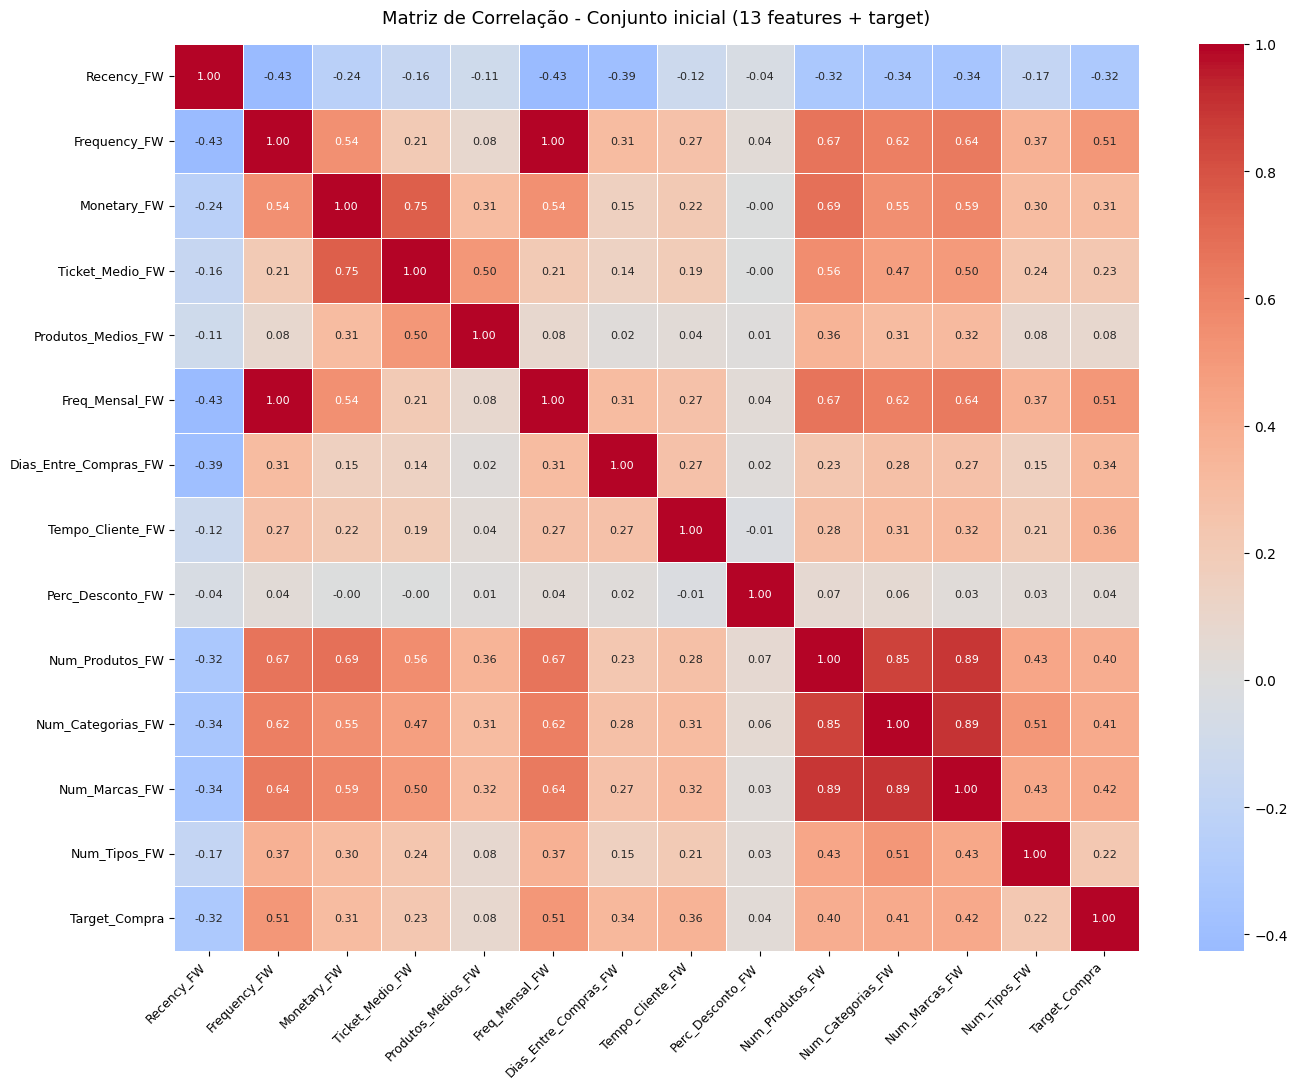

In [42]:
#Matriz de correlação sobre todas as features
corr_inicial = df_modelo_inicial.corr(numeric_only=True)

#Heatmap para visualização
plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_inicial,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Matriz de Correlação - Conjunto inicial (13 features + target)',
          fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

A matriz de correlação revela um padrão crítico entre `Frequency_FW` e `Freq_Mensal_FW`. As variáveis apresentam **correlação perfeita (r = 1,00)**, comprovando que a relação apresenta carácter determinístico e não estatística. Como tal, não é viável manter as duas no modelo, pois introduz multicolinearidade perfeita.

**Decisão:** remoção da variável `Frequency_FW` e manutenção da variável `Freq_Mensal_FW`. Esta escolha assenta na preferência pela abordagem *mensal*, visto que se trata de uma métrica comparável entre clientes com diferentes janelas de observação.

**Outras observações relevantes:**
- Correlações elevadas (mas não perfeitas) entre as variáveis de diversidade de produtos (`Num_Produtos_FW`, `Num_Categorias_FW`, `Num_Marcas_FW`, `Num_Tipos_FW`): estes resultados são expectáveis, uma vez que clientes que compram mais produtos tendem a explorar mais categorias/marcas. Como tal, estas variáveis são mantidas porque integram dimensões de diversidade conceptualmente distintas.
- `Recency_FW` apresenta correlação **negativa** com `Target_Compra`, sendo uma relação esperada, na medida em que clientes com compras mais recentes apresentam maior probabilidade de voltar a comprar.
- `Frequency_FW`/`Freq_Mensal_FW` apresentam correlação **positiva** com `Target_Compra`, sendo igualmente esperado, pois os clientes com maior frequência de compras na janela de features têm maior probabilidade de manter o comportamento de compra.

### **9.2. Conjunto final de features (após remoção de `Frequency_FW`)**

In [43]:
#Conjunto final de 12 features (após remoção de Frequency_FW por colinearidade perfeita com Freq_Mensal_FW)
features = [
    'Recency_FW',
    'Monetary_FW',
    'Ticket_Medio_FW',
    'Produtos_Medios_FW',
    'Freq_Mensal_FW',
    'Dias_Entre_Compras_FW',
    'Tempo_Cliente_FW',
    'Perc_Desconto_FW',
    'Num_Produtos_FW',
    'Num_Categorias_FW',
    'Num_Marcas_FW',
    'Num_Tipos_FW'
]

#Construir o dataframe final de modelação
df_modelo = df_features_fw.merge(df_target, on='Ref Cliente', how='left')
df_modelo = df_modelo[features + ['Target_Compra']].copy()

print(f"Dimensão do dataset de modelação: {df_modelo.shape}")
print(f"Features finais ({len(features)}):")
for fname in features:
    print(f"  - {fname}")
print(f"\nDistribuição Target_Compra:")
print(df_modelo['Target_Compra'].value_counts())
print(df_modelo['Target_Compra'].value_counts(normalize=True).round(4))

Dimensão do dataset de modelação: (2257, 13)
Features finais (12):
  - Recency_FW
  - Monetary_FW
  - Ticket_Medio_FW
  - Produtos_Medios_FW
  - Freq_Mensal_FW
  - Dias_Entre_Compras_FW
  - Tempo_Cliente_FW
  - Perc_Desconto_FW
  - Num_Produtos_FW
  - Num_Categorias_FW
  - Num_Marcas_FW
  - Num_Tipos_FW

Distribuição Target_Compra:
Target_Compra
0    1431
1     826
Name: count, dtype: int64
Target_Compra
0    0.634
1    0.366
Name: proportion, dtype: float64


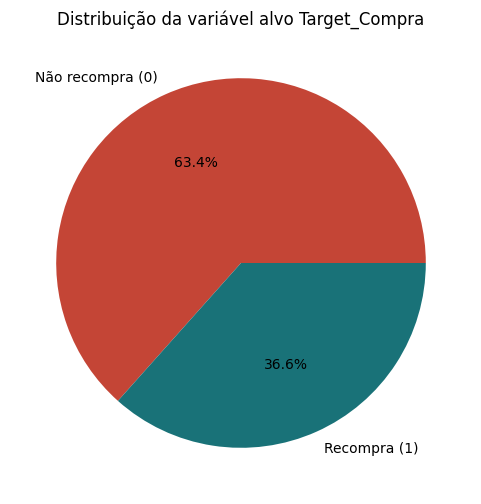

In [44]:
#Visualização da distribuição da variável alvo
df_target['Target_Compra'].value_counts().plot.pie(
    labels=['Não recompra (0)', 'Recompra (1)'],
    colors=['#C44536', '#197278'],
    autopct='%1.1f%%',
    figsize=(6, 6)
)
plt.title('Distribuição da variável alvo Target_Compra')
plt.ylabel('')
plt.show()

O dataset final de modelação é construído com base nos clientes que compraram pelo menos uma vez no período definido pela janela de features (últimos 180 dias antes do período de target), garantindo que todas as instâncias representam clientes com atividade recente e comportamento observável.

O **conjunto final de features** contempla **12 variáveis** após a remoção de `Frequency_FW`, acrescendo a variável alvo.

O desequilíbrio de classes observado (classe 0 / Não recompra = 63,4% e classe 1 / Recompra = 36,6%) reflete a natureza real do problema de negócio e será devidamente tratado na fase de modelação através de `class_weight='balanced'` e métricas mais adequadas ao problema em questão (Recall, F1-Score).

## **10. Preparação final para modelação**

Segue-se a identificação e tratamento dos valores omissos e infinitos existentes no dataset, mantendo as variáveis na escala original. O processo de normalização (`StandardScaler`) não é aplicado nesta fase, sendo implementado no processo de treino/validação cruzada dos notebooks da fase de modelação.

***Analisar valores nulos***

In [45]:
#Verificar quais as variáveis que apresentam valores nulos
print("Valores nulos por variável:")
nulos = df_modelo.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "Sem valores nulos.")

Valores nulos por variável:
Dias_Entre_Compras_FW    1393
dtype: int64


A análise dos valores nulos revela a existência de 1.393 valores omissos na variável `Dias_Entre_Compras`, correspondendo a clientes que realizaram apenas uma compra, não havendo intervalo de recompra. Como tal, procedeu-se ao preenchimento com o valor 0.

In [46]:
#Tratar valores nulos - preencher com 0 (semanticamente apropriado: sem desconto ou sem intervalo recorrente)
df_modelo['Dias_Entre_Compras_FW'] = df_modelo['Dias_Entre_Compras_FW'].fillna(0)

Após a substituição dos valores nulos por 0, recorre-se à análise de ocorrência de valores infinitos.

**Análise de valores infinitos**

In [47]:
#Verificar valores infinitos (podem surgir em divisões por zero)
print("\nValores infinitos por variável:")
infinitos = df_modelo[features].apply(lambda col: np.isinf(col).sum())
print(infinitos[infinitos > 0] if infinitos.sum() > 0 else "Sem valores infinitos.")


Valores infinitos por variável:
Sem valores infinitos.


A análise de valores infinitos não identificou qualquer ocorrência, pelo que não existem ações adicionais a tomar.

**Validação final do dataset**

In [48]:
#Validação final do dataset
#A normalização (StandardScaler) será aplicada via Pipeline nos notebooks de modelação para evitar data leakage

print(f"Dimensões finais: {df_modelo.shape}")
print(f"\nValores nulos remanescentes: {df_modelo.isnull().sum().sum()}")
print(f"\nEstatísticas das features:")
print(df_modelo[features].describe().round(2))

Dimensões finais: (2257, 13)

Valores nulos remanescentes: 0

Estatísticas das features:
       Recency_FW  Monetary_FW  Ticket_Medio_FW  Produtos_Medios_FW  \
count     2257.00      2257.00          2257.00             2257.00   
mean        68.06       485.99           186.80                5.94   
std         51.41      1234.34           294.21               11.26   
min          1.00         4.90             4.90                1.00   
25%         24.00        52.64            45.80                1.00   
50%         57.00       132.00            91.70                2.67   
75%        106.00       427.75           216.14                5.50   
max        180.00     25137.67          4550.67              154.00   

       Freq_Mensal_FW  Dias_Entre_Compras_FW  Tempo_Cliente_FW  \
count         2257.00                2257.00           2257.00   
mean             0.33                  18.14            789.17   
std              0.31                  31.15            885.76   
min    

## **11. Validação do Dataset final**

Criado e validado o dataset final para a fase de modelação, especificamente, para o problema de classificação supervisionada, importa definir a prioridade entre Falsos Negativos (FN) vs Falsos Positivos (FP).

- **Objetivo principal da PME:** Minimizar Falsos Negativos, na medida em que estes dizem respeito a clientes que voltariam efetivamente a comprar, embora não sendo identificados pelo modelo. Esta situação leva à perda de oportunidades comerciais e à subestimação do potencial do cliente e do seu valor expectável ao longo da relação com a empresa (CLV), resultando num impacto negativo para a PME.

Adicionalmente, a relevância atribuída aos Falsos Negativos está associada ao facto de a empresa ser caracterizada como uma PME, o que significa que os recursos ao nível das ações de marketing são escassos, aliado ao facto de possuir uma extensa base de clientes sem ser devidamente nutrida. Como tal, o peso associado à não identificação dos clientes que voltariam a comprar é suprior ao custo da realização de ações de marketing (comunicação e reativação) direcionadas a clientes que não voltariam a comprar.

A avaliação dos modelos de classificação nos próximos notebooks privilegiará a métrica de Recall, complementada com F1-Score.

***Primeiras 5 instâncias***

In [49]:
#Primeiras 5 linhas do dataset final
df_modelo.head()

,Recency_FW,Monetary_FW,Ticket_Medio_FW,Produtos_Medios_FW,Freq_Mensal_FW,Dias_Entre_Compras_FW,Tempo_Cliente_FW,Perc_Desconto_FW,Num_Produtos_FW,Num_Categorias_FW,Num_Marcas_FW,Num_Tipos_FW,Target_Compra
0,120,158.75,52.916667,4.333333,0.500000,30.0,180,0.04,1,1,1,1,0
1,180,65.60,65.600000,2.000000,0.166667,0.0,180,0.00,2,2,2,2,0
2,40,208.80,69.600000,1.333333,0.500000,70.0,1017,0.00,2,2,1,1,1
3,30,460.10,153.366667,3.666667,0.500000,75.0,298,0.00,4,3,3,1,1
4,31,519.25,259.625000,3.500000,0.333333,149.0,1588,0.00,6,3,4,1,0


In [50]:
#Dimensão final
print("Dimensão:", df_modelo.shape)

Dimensão: (2257, 13)


Os 5 primeiros registos confirmam que o dataset final apresenta uma elevada heterogeneidade entre os clientes nas variáveis comportamentais e transacionais, apresentando 2 em 5 clientes que foram classificados como clientes que poderão voltar a comprar nos próximos 90 dias.

Os clientes com valores superiores em `Freq_Mensal_FW` e `Monetary_FW` e menor `Recency_FW` estão, frequentemente, associados a perfis de maior atividade na janela de features, podendo ser classificados com `Target_Compra = 1`. Por outro lado, clientes que apresentam `Recency_FW` elevado e baixa atividade tendem a apresentar `Target_Compra = 0`.

In [51]:
#Estatísticas descritivas finais
df_modelo.describe()

,Recency_FW,Monetary_FW,Ticket_Medio_FW,Produtos_Medios_FW,Freq_Mensal_FW,Dias_Entre_Compras_FW,Tempo_Cliente_FW,Perc_Desconto_FW,Num_Produtos_FW,Num_Categorias_FW,Num_Marcas_FW,Num_Tipos_FW,Target_Compra
count,2257.000000,2257.000000,2257.000000,2257.000000,2257.000000,2257.000000,2257.000000,2257.000000,2257.000000,2257.000000,2257.000000,2257.000000,2257.000000
mean,68.057599,485.994497,186.796703,5.943936,0.334219,18.139996,789.170580,0.010251,4.043420,2.277359,2.380151,1.200709,0.365973
std,51.413024,1234.337178,294.207316,11.255951,0.305460,31.154008,885.760925,0.093846,5.224047,2.017474,2.484868,0.544996,0.481809
min,1.000000,4.900000,4.900000,1.000000,0.166667,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,52.640000,45.800000,1.000000,0.166667,0.000000,97.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
50%,57.000000,132.000000,91.700000,2.666667,0.166667,0.000000,361.000000,0.000000,2.000000,1.000000,1.000000,1.000000,0.000000
75%,106.000000,427.750000,216.135714,5.500000,0.333333,29.500000,1359.000000,0.000000,5.000000,3.000000,3.000000,1.000000,1.000000
max,180.000000,25137.670000,4550.666000,154.000000,2.500000,177.000000,3584.000000,4.344392,57.000000,13.000000,20.000000,7.000000,1.000000


As estatísticas descritivas do dataset final confirmam a elevada heterogeneidade da base de clientes da empresa, sendo a mesma composta, em simultâneo, por clientes com comportamento de compra ocasional e de baixo valor e por um conjunto restrito de clientes bastante ativos com elevado volume e valor de compras.

A análise revela, mais especificamente, que o dataset preparado para a modelação é composto por um total de 2.257 clientes com os seguintes pontos de interesse:
- A variável `Recency_FW` apresenta uma mediana de 57 dias, traduzindo que 50% dos clientes realizou a última compra há menos de dois meses.
- A variável `Monetary_FW`, que corresponde ao valor total gasto por cliente, revela uma forte assimetria à direita, apresentando uma mediana de 132€ e um máximo superior a 25.000€, sugerindo a existência de clientes com um valor bastante elevado.
- O valor da frequência mensal de compra (`Freq_Mensal_FW`) é bastante reduzido, comprovado por uma mediana igual a 0,17 compras por mês, o que traduz ciclos de compra com intervalos significativos.
- A diversidade de compra associada às características dos produtos adquiridos é reduzida na maioria dos clientes, significando que adquirem produtos de poucas categorias, marcas e tipos distintos.
- Os valores próximos de zero na variável `Perc_Desconto_FW` na maioria dos clientes revalam reduzida opção por descontos.

No que diz respeito à variável alvo `Target_Compra`, o desequilíbrio moderado de classes (36,6% dos clientes realizaram uma nova compra na janela de target vs 63,4% não efetuaram qualquer recompra) verificado reflete a natureza real do problema. Este desequilíbrio será minimizado, conforme referido anteriormente, na criação dos modelos através do parâmetro `class_weight='balanced'` e será avaliado com as métricas Recall e F1-Score.

## **12. Exportação**

O último passo a realizar no presente notebook consiste na exportação em formato CSV do dataset para a componente de classificação (`df_modelo_compra`) e do dataset para a componente de clustering (`df_clientes_enriquecido`).

In [52]:
#Exportação dos dois datasets produzidos
#Os caminhos estão centralizados no início para facilitar manutenção futura
caminho_modelo    = '/content/drive/MyDrive/dataset_modelo_compra.csv'
caminho_clientes  = '/content/drive/MyDrive/df_clientes_enriquecido.csv'

#(1) Dataset de modelação - para classificação
df_modelo.to_csv(caminho_modelo, index=False)

print(f'[1] Dataset de modelação exportado: {caminho_modelo}')
print(f'    Dimensão: {df_modelo.shape[0]:,} clientes × {df_modelo.shape[1]} colunas'.replace(',', '.'))
print(f'    Inclui: 12 features na janela temporal + variável alvo Target_Compra')

#(2) Dataset de clientes enriquecido - para clustering)
df_clientes.to_csv(caminho_clientes, index=False)

print(f'\n[2] Dataset de clientes enriquecido exportado: {caminho_clientes}')
print(f'    Dimensão: {df_clientes.shape[0]:,} clientes × {df_clientes.shape[1]} colunas'.replace(',', '.'))
print(f'    Inclui: RFM (Recency, Frequency, Monetary) + features de diversidade e comportamento')

[1] Dataset de modelação exportado: /content/drive/MyDrive/dataset_modelo_compra.csv
    Dimensão: 2.257 clientes × 13 colunas
    Inclui: 12 features na janela temporal + variável alvo Target_Compra

[2] Dataset de clientes enriquecido exportado: /content/drive/MyDrive/df_clientes_enriquecido.csv
    Dimensão: 13.074 clientes × 17 colunas
    Inclui: RFM (Recency, Frequency, Monetary) + features de diversidade e comportamento


## **13. Principais conclusões**

A fase de Preparação de Dados da CRISP-DM permitiu a produção dos datasets que servirão de base às diferentes componentes analíticas da fase de modelação. Os principais resultados são apresentados de seguida:

- **Abordagem janela temporal:** Criação de janela de features de 180 dias (4 jul – 31 dez 2025) e de janela de target de 90 dias (31 dez 2025 – 31 mar 2026).
- **Dimensão final de 2.257 clientes ativos:** Após aplicação do filtro de clientes com pelo menos uma compra na janela de features, a base de clientes é reduzida de 13.074 para 2.257 clientes, assegurando a observação de comportamento recente.
- **12 features finais (após remoção de Frequency_FW):** Houve uma redução do conjunto inicial de 13 features para 12 features, dada a identificação de correlação perfeita (r = 1,00) entre Frequency_FW com Freq_Mensal_FW.
- **Distribuição da variável alvo - 1.431 (63,4%) / 826 (36,6%):** Constata-se um desbalanceamento moderado, que será mitigado através de `class_weight='balanced'` na fase de modelação.
- **Integridade do dataset garantida:** Tratamento de features de forma a garantir a ausência de NaN e infinitos no dataset final. Todo o conjunto de features foi mantido na escala original, pois o processo de normalização (StandardScaler) será executado no interior das *Pipelines* de cross-validation.
- **Próximos passos:** O dataset `dataset_modelo_compra.csv` serve de base para o desenvolvimento dos dois próximos notebooks (NB3 - baseline de 4 algoritmos de classificação e NB4 - Grid Search + Seleção de Features). A principal métrica escolhida para a avaliação do modelo de classificação consiste no Recall, como forma de minimizar a ocorrência de Falsos Negativos.